# Dealing with Data Using pandas
## From raw customer data to useful business information

`pandas` is the standard Python library for working with **tabular data**.

In this notebook we use a synthetic e-commerce customer dataset to move from basic DataFrame operations to a small but realistic customer-analytics workflow.

### Learning objectives

By the end of the notebook, you should be able to:

- understand the `DataFrame` and `Series` abstractions;
- load, inspect, and validate a dataset;
- select rows and columns using `[]`, `.loc`, `.iloc`, and `.query()`;
- filter observations using multiple conditions;
- create new variables using vectorized operations;
- work safely with missing values;
- transform text, categorical, and date columns;
- sort, count, and summarize data;
- use `groupby()` and named aggregations;
- create pivot tables and contingency tables;
- combine multiple tables using `merge()`;
- identify possible outliers;
- compute simple correlations;
- make exploratory plots directly from pandas;
- export a cleaned dataset;
- avoid common pandas mistakes.

> **Important:** the dataset used here is synthetic and is intended only for teaching.


# 0. Setup

We start by importing the libraries used throughout the notebook.

We also set a random seed so that the synthetic dataset is always the same when the notebook is re-run.

In [86]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 2)

## 0.1 Create or load the dataset

In a real project we would usually receive data from a CSV file, database, CRM, e-commerce platform, or analytics system.

To keep this notebook fully reproducible, the next cell:

1. looks for `customer_data.csv`;
2. loads it if it exists;
3. otherwise generates a synthetic customer cohort and saves it as `customer_data.csv`.

The dataset contains one row per customer and includes demographics, loyalty membership, website activity, annual income, campaign assignment, and monthly spending measured before and after a marketing campaign.


In [87]:
DATA_PATH = Path("customer_data.csv")

if DATA_PATH.exists():
    customers = pd.read_csv(DATA_PATH, parse_dates=["signup_date"])
else:
    n = 300

    age = rng.integers(20, 71, size=n)
    gender = rng.choice(["Female", "Male"], size=n, p=[0.52, 0.48])
    city = rng.choice(
        ["Trieste", "Udine", "Gorizia", "Pordenone"],
        size=n,
        p=[0.38, 0.27, 0.15, 0.20]
    )
    loyalty_member = rng.choice(["yes", "no"], size=n, p=[0.42, 0.58])
    campaign = rng.choice(["Discount", "Control"], size=n)

    site_visits = rng.normal(
        18 + 0.08 * (age - 40) + 4 * (loyalty_member == "yes"),
        6,
        size=n,
    )
    site_visits = np.clip(site_visits, 1, None)

    annual_income = rng.normal(
        42000 + 450 * (age - 30),
        12000,
        size=n,
    )
    annual_income = np.clip(annual_income, 15000, None)

    spend_baseline = (
        60
        + 0.0015 * annual_income
        + 2.2 * site_visits
        + 35 * (loyalty_member == "yes")
        + rng.normal(0, 25, size=n)
    )

    campaign_effect = np.where(campaign == "Discount", 28.0, 5.0)
    spend_12w = spend_baseline + campaign_effect + rng.normal(0, 18, size=n)

    start = np.datetime64("2026-01-01")
    signup_date = start + rng.integers(0, 180, size=n).astype("timedelta64[D]")

    customers = pd.DataFrame({
        "customer_id": np.arange(1001, 1001 + n),
        "age": age,
        "gender": gender,
        "city": city,
        "loyalty_member": loyalty_member,
        "site_visits": site_visits.round(1),
        "annual_income": annual_income.round(0),
        "campaign": campaign,
        "spend_baseline": spend_baseline.round(0),
        "spend_12w": spend_12w.round(0),
        "signup_date": pd.to_datetime(signup_date),
    })

    # Introduce some missing values to make the cleaning section realistic.
    for column, proportion in {
        "site_visits": 0.06,
        "annual_income": 0.04,
        "spend_12w": 0.05,
    }.items():
        idx = rng.choice(
            customers.index,
            size=int(proportion * n),
            replace=False
        )
        customers.loc[idx, column] = np.nan

    customers.to_csv(DATA_PATH, index=False)

customers.head()


,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
0,1001,24,Male,Trieste,yes,14.8,51163.0,Control,178.0,177.0,2026-06-15
1,1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2026-03-29
2,1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,2026-03-04
3,1004,42,Male,Trieste,no,29.0,31077.0,Discount,191.0,219.0,2026-01-20
4,1005,42,Female,Trieste,no,NaN,30274.0,Control,117.0,132.0,2026-03-12


# 1. Understanding the pandas data model

A pandas table is a **DataFrame**.

A single column is usually a **Series**.

Both objects have an **index**, which pandas uses to identify and align observations.

In [88]:
type(customers), type(customers["age"])

(pandas.DataFrame, pandas.Series)

In [89]:
customers.index

RangeIndex(start=0, stop=300, step=1)

The default index is an integer sequence, but it does **not** have to correspond to the customer identifier.

For customer data, keeping a dedicated `customer_id` column is often clearer than assuming that row number = customer identity.


# 2. First inspection: understand before transforming

A useful rule is:

> **Never start cleaning or modeling a dataset before you understand its structure.**

We first inspect dimensions, column names, data types, and a few observations.

In [90]:
customers.shape

(300, 11)

In [91]:
customers.columns.tolist()

['customer_id',
 'age',
 'gender',
 'city',
 'loyalty_member',
 'site_visits',
 'annual_income',
 'campaign',
 'spend_baseline',
 'spend_12w',
 'signup_date']

In [92]:
customers.dtypes

customer_id                int64
age                        int64
gender                       str
city                         str
loyalty_member               str
site_visits              float64
annual_income            float64
campaign                     str
spend_baseline           float64
spend_12w                float64
signup_date       datetime64[us]
dtype: object

In [93]:
customers.head()

,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
0,1001,24,Male,Trieste,yes,14.8,51163.0,Control,178.0,177.0,2026-06-15
1,1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2026-03-29
2,1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,2026-03-04
3,1004,42,Male,Trieste,no,29.0,31077.0,Discount,191.0,219.0,2026-01-20
4,1005,42,Female,Trieste,no,NaN,30274.0,Control,117.0,132.0,2026-03-12


In [94]:
customers.tail(3)

,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
297,1298,42,Male,Udine,no,13.8,38069.0,Discount,191.0,201.0,2026-05-15
298,1299,34,Female,Gorizia,no,NaN,36239.0,Discount,148.0,170.0,2026-02-14
299,1300,21,Male,Pordenone,yes,23.2,25264.0,Control,194.0,207.0,2026-04-03


In [95]:
customers.sample(5, random_state=RANDOM_SEED)

,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
203,1204,55,Male,Trieste,yes,31.2,53274.0,Control,241.0,242.0,2026-05-31
266,1267,42,Female,Udine,no,16.5,46310.0,Discount,199.0,210.0,2026-03-21
152,1153,66,Male,Pordenone,yes,22.9,93171.0,Discount,270.0,298.0,2026-06-12
9,1010,24,Male,Udine,no,10.7,15000.0,Discount,149.0,172.0,2026-01-13
233,1234,58,Female,Udine,no,18.3,83095.0,Control,223.0,214.0,2026-04-22


`sample()` is often more informative than looking only at the first rows, because the first rows may not be representative of the whole dataset.

In [96]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     300 non-null    int64         
 1   age             300 non-null    int64         
 2   gender          300 non-null    str           
 3   city            300 non-null    str           
 4   loyalty_member  300 non-null    str           
 5   site_visits     282 non-null    float64       
 6   annual_income   288 non-null    float64       
 7   campaign        300 non-null    str           
 8   spend_baseline  300 non-null    float64       
 9   spend_12w       285 non-null    float64       
 10  signup_date     300 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 25.9 KB


## 2.1 Numerical summary

`describe()` gives a fast summary of numerical variables.

In [97]:
customers.describe()

,customer_id,age,site_visits,annual_income,spend_baseline,spend_12w,signup_date
count,300.00,300.00,282.00,288.00,300.00,285.00,300
mean,1150.50,44.93,20.31,47010.68,187.11,204.31,2026-04-03 18:04:48
min,1001.00,20.00,2.30,15000.00,84.00,90.00,2026-01-01 00:00:00
25%,1075.75,34.00,15.65,37239.25,157.75,170.00,2026-02-15 00:00:00
50%,1150.50,45.00,20.35,47133.00,187.50,203.00,2026-04-07 00:00:00
75%,1225.25,56.25,25.30,55483.50,217.25,234.00,2026-05-21 00:00:00
max,1300.00,70.00,39.50,93171.00,303.00,314.00,2026-06-29 00:00:00
std,86.75,13.87,7.01,13836.70,42.30,46.84,NaN


For categorical variables, use `include="object"` or `include="all"`.

In [98]:
customers.describe(include="object")

/var/folders/6s/6yxx8r211kj6vxx_g3yvfp280000gp/T/ipykernel_43111/1913638412.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers.describe(include="object")


,gender,city,loyalty_member,campaign
count,300,300,300,300
unique,2,4,2,2
top,Male,Trieste,no,Discount
freq,151,110,167,155


## 2.2 A compact data-quality report

A very common first step is to summarize:

- data type;
- number of missing values;
- percentage missing;
- number of unique values.

In [99]:
quality_report = pd.DataFrame({
    "dtype": customers.dtypes,
    "missing": customers.isna().sum(),
    "missing_%": customers.isna().mean().mul(100).round(1),
    "n_unique": customers.nunique(dropna=True),
})

quality_report

,dtype,missing,missing_%,n_unique
customer_id,int64,0,0.0,300
age,int64,0,0.0,50
gender,str,0,0.0,2
city,str,0,0.0,4
loyalty_member,str,0,0.0,2
site_visits,float64,18,6.0,173
annual_income,float64,12,4.0,288
campaign,str,0,0.0,2
spend_baseline,float64,0,0.0,139
spend_12w,float64,15,5.0,152


### Interpretation

This table immediately helps answer questions such as:

- Which variables contain missing values?
- Are numerical variables stored as numbers?
- Does a supposedly categorical column contain too many distinct values?
- Is an identifier actually unique?

In [100]:
customers["customer_id"].is_unique

True

# 3. Selecting columns

There are two common patterns:

```python
df["column"]
```

returns one column as a `Series`.

```python
df[["column1", "column2"]]
```

returns a `DataFrame`.

In [101]:
customers["age"].head()

0    24
1    59
2    53
3    42
4    42
Name: age, dtype: int64

In [102]:
customers[["age", "site_visits", "annual_income", "spend_baseline", "spend_12w"]].head()


,age,site_visits,annual_income,spend_baseline,spend_12w
0,24,14.8,51163.0,178.0,177.0
1,59,18.4,NaN,215.0,217.0
2,53,37.8,36913.0,203.0,248.0
3,42,29.0,31077.0,191.0,219.0
4,42,NaN,30274.0,117.0,132.0


A useful habit in larger analyses is to define the variables of interest explicitly.

In [103]:
commercial_variables = [
    "customer_id",
    "age",
    "site_visits",
    "annual_income",
    "spend_baseline",
    "spend_12w",
]

customers[commercial_variables].head()


,customer_id,age,site_visits,annual_income,spend_baseline,spend_12w
0,1001,24,14.8,51163.0,178.0,177.0
1,1002,59,18.4,NaN,215.0,217.0
2,1003,53,37.8,36913.0,203.0,248.0
3,1004,42,29.0,31077.0,191.0,219.0
4,1005,42,NaN,30274.0,117.0,132.0


# 4. Selecting rows: `.loc` versus `.iloc`

- `.loc` is **label-based**.
- `.iloc` is **position-based**.

This distinction becomes important when the DataFrame index is no longer `0, 1, 2, ...`.

In [104]:
customers.loc[0:4, ["customer_id", "age", "site_visits"]]

,customer_id,age,site_visits
0,1001,24,14.8
1,1002,59,18.4
2,1003,53,37.8
3,1004,42,29.0
4,1005,42,NaN


In [105]:
customers.iloc[0:5, 0:4]

,customer_id,age,gender,city
0,1001,24,Male,Trieste
1,1002,59,Male,Pordenone
2,1003,53,Female,Gorizia
3,1004,42,Male,Trieste
4,1005,42,Female,Trieste


Notice an important difference:

- `.loc[0:4]` includes label `4`;
- `.iloc[0:5]` stops before position `5`.

This follows Python's usual half-open slicing convention only for `.iloc`.

## 4.1 Setting an index

We can temporarily use `customer_id` as the index.

In [109]:
customers_by_id = customers.set_index("customer_id")
customers_by_id.head()

,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
customer_id,,,,,,,,,,
1001,24,Male,Trieste,yes,14.8,51163.0,Control,178.0,177.0,2026-06-15
1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2026-03-29
1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,2026-03-04
1004,42,Male,Trieste,no,29.0,31077.0,Discount,191.0,219.0,2026-01-20
1005,42,Female,Trieste,no,NaN,30274.0,Control,117.0,132.0,2026-03-12


In [ ]:
customers_by_id.loc[1005]

age                                42
gender                         Female
city                          Trieste
loyalty_member                     no
site_visits                       NaN
annual_income                 30274.0
campaign                      Control
spend_baseline                  117.0
spend_12w                       132.0
signup_date       2026-03-12 00:00:00
Name: 1005, dtype: object

# 5. Filtering rows with Boolean masks

A Boolean mask is a `Series` containing `True` or `False` for each row.

In [ ]:
older_mask = customers["age"] >= 65
older_mask.head()

0    False
1    False
2    False
3    False
4    False
Name: age, dtype: bool

In [ ]:
customers.loc[older_mask, ["customer_id", "age", "spend_baseline"]].head()

,customer_id,age,spend_baseline
11,1012,69,221.0
23,1024,67,133.0
34,1035,65,209.0
45,1046,69,268.0
47,1048,65,188.0


## 5.1 Multiple conditions

Use:

- `&` for AND;
- `|` for OR;
- `~` for NOT.

Each condition should be enclosed in parentheses.

In [ ]:
high_value_subset = customers.loc[
    (customers["age"] >= 40)
    & (customers["loyalty_member"] == "yes")
    & (customers["spend_baseline"] >= 180),
    ["customer_id", "age", "loyalty_member", "spend_baseline", "annual_income"]
]

high_value_subset.head(10)


,customer_id,age,loyalty_member,spend_baseline,annual_income
1,1002,59,yes,215.0,NaN
2,1003,53,yes,203.0,36913.0
5,1006,63,yes,266.0,35639.0
11,1012,69,yes,221.0,57596.0
12,1013,57,yes,222.0,79302.0
13,1014,58,yes,209.0,37114.0
15,1016,60,yes,303.0,75970.0
16,1017,46,yes,229.0,54600.0
20,1021,45,yes,248.0,58081.0
24,1025,59,yes,251.0,58990.0


## 5.2 Membership with `.isin()`

Suppose we want customers located in either Trieste or Udine.


In [ ]:
northeast_subset = customers[
    customers["city"].isin(["Trieste", "Udine"])
]

northeast_subset["city"].value_counts()

city
Trieste    110
Udine       89
Name: count, dtype: int64

## 5.3 Filtering with `.between()`

For intervals, `.between()` is often more readable than two comparisons.

In [ ]:
customers.loc[
    customers["age"].between(50, 60),
    ["customer_id", "age", "site_visits"]
].head()

,customer_id,age,site_visits
1,1002,59,18.4
2,1003,53,37.8
7,1008,55,7.8
12,1013,57,18.8
13,1014,58,24.3


## 5.4 Using `.query()`

For readable filters, `query()` can be convenient.

In [ ]:
customers.query(
    "age >= 40 and loyalty_member == 'yes' and spend_baseline >= 180"
).head()


,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date
1,1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2026-03-29
2,1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,2026-03-04
5,1006,63,Male,Trieste,yes,21.7,35639.0,Discount,266.0,291.0,2026-02-12
11,1012,69,Male,Trieste,yes,NaN,57596.0,Control,221.0,203.0,2026-06-17
12,1013,57,Female,Pordenone,yes,18.8,79302.0,Control,222.0,226.0,2026-05-18


# 6. Creating commercially meaningful derived variables

A major strength of pandas is **vectorization**: operations are applied to entire columns at once.

This is usually clearer and faster than writing a Python loop over rows.


## 6.1 Change in monthly spending

We define:

\[
\Delta Spend = Spend_{after} - Spend_{baseline}
\]

A positive value means monthly customer spending increased after the campaign.


In [ ]:
customers["spend_change"] = (
    customers["spend_12w"] - customers["spend_baseline"]
)

customers[
    ["customer_id", "campaign", "spend_baseline", "spend_12w", "spend_change"]
].head()


,customer_id,campaign,spend_baseline,spend_12w,spend_change
0,1001,Control,178.0,177.0,-1.0
1,1002,Control,215.0,217.0,2.0
2,1003,Discount,203.0,248.0,45.0
3,1004,Discount,191.0,219.0,28.0
4,1005,Control,117.0,132.0,15.0


## 6.2 Boolean variables

A Boolean column is useful for questions that naturally have a yes/no interpretation.


In [ ]:
customers["high_value_baseline"] = (
    customers["spend_baseline"] >= 180
)

customers[
    ["spend_baseline", "high_value_baseline"]
].head()


,spend_baseline,high_value_baseline
0,178.0,False
1,215.0,True
2,203.0,True
3,191.0,True
4,117.0,False


## 6.3 Categorizing website activity with `pd.cut`

We can convert a continuous variable into intervals.


In [111]:
customers["engagement_category"] = pd.cut(
    customers["site_visits"],
    bins=[0, 10, 20, 30, np.inf],
    labels=["Low", "Moderate", "High", "Very high"],
    right=False,
)

customers[["site_visits", "engagement_category"]].head(10)


,site_visits,engagement_category
0,14.8,Moderate
1,18.4,Moderate
2,37.8,Very high
3,29.0,High
4,NaN,NaN
5,21.7,High
6,13.8,Moderate
7,7.8,Low
8,20.5,High
9,10.7,Moderate


## 6.4 Age groups with `pd.cut`

This is preferable to a long `apply()` function when the transformation is simply based on intervals.

In [ ]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[0, 50, 65, np.inf],
    labels=["<50", "50–64", "65+"],
    right=False,
)

customers["age_group"].value_counts(sort=False)

age_group
<50      182
50–64     92
65+       26
Name: count, dtype: int64

## 6.5 `np.where()` for conditional transformations

Suppose we define a commercially meaningful response as an increase in monthly spending of at least €20.


In [ ]:
customers["meaningful_increase"] = np.where(
    customers["spend_change"] >= 20,
    "yes",
    "no"
)

customers["meaningful_increase"].value_counts(dropna=False)


meaningful_increase
no     174
yes    126
Name: count, dtype: int64

Notice that rows with missing `spend_12w` need special attention: a derived variable should not silently convert missing follow-up information into a valid business outcome.

Let's correct that.


In [ ]:
customers["meaningful_increase"] = pd.Series(
    np.where(customers["spend_change"] >= 20, "yes", "no"),
    index=customers.index,
    dtype="object",
)

customers.loc[
    customers["spend_change"].isna(),
    "meaningful_increase"
] = np.nan

customers["meaningful_increase"].value_counts(dropna=False)


meaningful_increase
no     159
yes    126
NaN     15
Name: count, dtype: int64

# 7. Missing data

Missing data are not merely a technical inconvenience. They can affect business conclusions and downstream models.

The first questions are:

1. **How much data are missing?**
2. **In which variables?**
3. **Are missing values concentrated in particular groups?**
4. **Why are they missing?**

The last question cannot be answered from pandas alone; it requires domain knowledge and information about data collection.


In [ ]:
customers.isna().sum().sort_values(ascending=False)

site_visits            18
engagement_category    18
spend_12w              15
spend_change           15
meaningful_increase    15
annual_income          12
customer_id             0
age                     0
gender                  0
city                    0
loyalty_member          0
campaign                0
spend_baseline          0
signup_date             0
high_value_baseline     0
age_group               0
dtype: int64

In [ ]:
(
    customers.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(1)
)

site_visits            6.0
engagement_category    6.0
spend_12w              5.0
spend_change           5.0
meaningful_increase    5.0
annual_income          4.0
customer_id            0.0
age                    0.0
gender                 0.0
city                   0.0
loyalty_member         0.0
campaign               0.0
spend_baseline         0.0
signup_date            0.0
high_value_baseline    0.0
age_group              0.0
dtype: float64

## 7.1 Complete-case analysis

`dropna()` removes observations containing missing values.

This is simple, but potentially wasteful and potentially biased.

In [ ]:
complete_cases = customers.dropna(
    subset=["site_visits", "annual_income", "spend_12w"]
)

print("Original:", customers.shape)
print("Complete cases:", complete_cases.shape)


Original: (300, 16)
Complete cases: (255, 16)


## 7.2 Imputation with a median

For demonstration, we fill missing website-activity values using the median.

We preserve the original column and create a new one so the transformation is transparent.


In [ ]:
customers["site_visits_imputed"] = customers["site_visits"].fillna(
    customers["site_visits"].median()
)

customers.loc[
    customers["site_visits"].isna(),
    ["customer_id", "site_visits", "site_visits_imputed"]
].head()


,customer_id,site_visits,site_visits_imputed
4,1005,NaN,20.35
11,1012,NaN,20.35
23,1024,NaN,20.35
28,1029,NaN,20.35
92,1093,NaN,20.35


## 7.3 Group-wise imputation

Sometimes a group-specific summary is more appropriate than one global value.

For example, we can impute annual income using the median within each gender group.


In [113]:
customers["annual_income_imputed"] = (
    customers["annual_income"]
    .fillna(
        customers.groupby("gender")["annual_income"].transform("median")
    )
)

customers.loc[
    customers["annual_income"].isna(),
    ["customer_id", "gender", "annual_income", "annual_income_imputed"]
].head()


,customer_id,gender,annual_income,annual_income_imputed
1,1002,Male,NaN,46318.5
22,1023,Female,NaN,48456.0
57,1058,Male,NaN,46318.5
61,1062,Male,NaN,46318.5
99,1100,Female,NaN,48456.0


### `agg()` versus `transform()`

- `groupby(...).agg(...)` reduces each group to one row.
- `groupby(...).transform(...)` returns a result aligned with the original DataFrame.

This makes `transform()` especially useful for group-wise normalization and imputation.

# 8. Text, categorical, and date data

Real-world datasets contain more than numbers.

## 8.1 String operations

The `.str` accessor applies vectorized string operations.

In [115]:
customers["city_upper"] = customers["city"].str.upper()
customers[["city", "city_upper"]].head()

,city,city_upper
0,Trieste,TRIESTE
1,Pordenone,PORDENONE
2,Gorizia,GORIZIA
3,Trieste,TRIESTE
4,Trieste,TRIESTE


## 8.2 Categorical data

Columns with a small number of repeated categories can be stored as `category`.

In [ ]:
categorical_columns = [
    "gender",
    "city",
    "loyalty_member",
    "campaign",
    "age_group",
    "engagement_category",
]

for col in categorical_columns:
    customers[col] = customers[col].astype("category")

customers[categorical_columns].dtypes


gender                 category
city                   category
loyalty_member         category
campaign               category
age_group              category
engagement_category    category
dtype: object

## 8.3 Dates

The `.dt` accessor exposes components of datetime columns.

In [ ]:
customers["signup_month"] = customers["signup_date"].dt.month
customers["signup_weekday"] = customers["signup_date"].dt.day_name()

customers[
    ["signup_date", "signup_month", "signup_weekday"]
].head()


,signup_date,signup_month,signup_weekday
0,2026-06-15,6,Monday
1,2026-03-29,3,Sunday
2,2026-03-04,3,Wednesday
3,2026-01-20,1,Tuesday
4,2026-03-12,3,Thursday


# 9. Sorting and ranking

Sorting is useful for inspection, reporting, and quality control.

In [ ]:
customers.sort_values(
    ["spend_baseline", "age"],
    ascending=[False, False]
)[
    ["customer_id", "age", "spend_baseline"]
].head(10)


,customer_id,age,spend_baseline
15,1016,60,303.0
70,1071,60,285.0
94,1095,65,282.0
290,1291,61,279.0
277,1278,59,277.0
199,1200,69,276.0
289,1290,44,273.0
61,1062,57,271.0
152,1153,66,270.0
45,1046,69,268.0


We can also rank observations without physically reordering the DataFrame.

In [ ]:
customers["spend_rank"] = customers["spend_baseline"].rank(
    method="min",
    ascending=False
)

customers[
    ["customer_id", "spend_baseline", "spend_rank"]
].sort_values("spend_rank").head()


,customer_id,spend_baseline,spend_rank
15,1016,303.0,1.0
70,1071,285.0,2.0
94,1095,282.0,3.0
290,1291,279.0,4.0
277,1278,277.0,5.0


# 10. Counting categorical variables

`value_counts()` is one of the fastest ways to understand a categorical variable.

In [ ]:
customers["loyalty_member"].value_counts()


loyalty_member
no     167
yes    133
Name: count, dtype: int64

In [ ]:
customers["loyalty_member"].value_counts(normalize=True).mul(100).round(1)


loyalty_member
no     55.7
yes    44.3
Name: proportion, dtype: float64

## 10.1 Cross-tabulation

A contingency table lets us compare two categorical variables.

In [ ]:
pd.crosstab(
    customers["campaign"],
    customers["meaningful_increase"],
    margins=True
)


meaningful_increase,no,yes,All
campaign,,,
Control,110,27,137
Discount,49,99,148
All,159,126,285


We can normalize by row to obtain within-campaign percentages.

In [ ]:
pd.crosstab(
    customers["campaign"],
    customers["meaningful_increase"],
    normalize="index"
).mul(100).round(1)


meaningful_increase,no,yes
campaign,,
Control,80.3,19.7
Discount,33.1,66.9


# 11. Grouping and aggregation

`groupby()` implements the classic **split–apply–combine** pattern:

1. split rows into groups;
2. apply a function to each group;
3. combine the results.

## 11.1 One summary statistic

In [ ]:
customers.groupby("campaign", observed=True)["spend_change"].mean()


campaign
Control      6.74
Discount    27.29
Name: spend_change, dtype: float64

## 11.2 Several statistics at once

In [ ]:
customers.groupby("campaign", observed=True).agg(
    n=("customer_id", "size"),
    mean_age=("age", "mean"),
    mean_baseline_spend=("spend_baseline", "mean"),
    mean_change=("spend_change", "mean"),
    median_change=("spend_change", "median"),
    sd_change=("spend_change", "std"),
)


,n,mean_age,mean_baseline_spend,mean_change,median_change,sd_change
campaign,,,,,,
Control,145,45.03,185.08,6.74,8.0,16.15
Discount,155,44.84,189.01,27.29,28.0,19.80


## 11.3 Grouping by multiple variables

In [ ]:
customers.groupby(
    ["campaign", "age_group"],
    observed=True
).agg(
    n=("customer_id", "size"),
    mean_change=("spend_change", "mean"),
    response_rate=(
        "meaningful_increase",
        lambda x: (x == "yes").mean()
    ),
)


n  mean_change  response_rate
campaign age_group                                
Control  <50        88         9.24           0.19
         50–64      42         1.77           0.21
         65+        15         6.14           0.07
Discount <50        94        26.59           0.65
         50–64      50        28.87           0.62
         65+        11        26.45           0.64

## 11.4 Why `size()` and `count()` are different

- `size()` counts rows.
- `count()` counts **non-missing values** in the selected column.

In [ ]:
customers.groupby("campaign", observed=True).agg(
    rows=("customer_id", "size"),
    observed_followups=("spend_12w", "count"),
)


,rows,observed_followups
campaign,,
Control,145,137
Discount,155,148


# 12. Pivot tables

Pivot tables summarize data across two or more dimensions.

Here we compare mean spending change by campaign and loyalty-membership status.


In [ ]:
pd.pivot_table(
    customers,
    values="spend_change",
    index="loyalty_member",
    columns="campaign",
    aggfunc="mean",
)


campaign,Control,Discount
loyalty_member,,
no,6.18,28.29
yes,7.41,25.90


We can ask for several statistics simultaneously.

In [ ]:
pd.pivot_table(
    customers,
    values="spend_change",
    index="age_group",
    columns="campaign",
    aggfunc=["mean", "median", "count"],
    observed=True,
)


mean           median            count         
campaign  Control Discount Control Discount Control Discount
age_group                                                   
<50          9.24    26.59    10.0     28.0      83       91
50–64        1.77    28.87     1.5     30.5      40       46
65+          6.14    26.45     8.0     30.0      14       11

# 13. Combining tables with `merge()`

Customer information is rarely stored in one giant table.

A more realistic structure might include:

- one **customer table**;
- one **order table**;
- one **campaign-interaction table**;
- one **support table**.

The key operation for combining related tables is `merge()`.


## 13.1 Create a second table: campaign touchpoints


In [ ]:
touchpoint_sample = customers[
    ["customer_id", "signup_date"]
].sample(
    240,
    random_state=RANDOM_SEED
).copy()

touchpoints = pd.DataFrame({
    "customer_id": touchpoint_sample["customer_id"].to_numpy(),
    "touchpoint_date": (
        touchpoint_sample["signup_date"].to_numpy()
        + pd.to_timedelta(
            rng.integers(20, 60, size=len(touchpoint_sample)),
            unit="D"
        )
    ),
    "email_open_rate_pct": rng.integers(0, 101, size=len(touchpoint_sample)),
})

touchpoints.head()


,customer_id,touchpoint_date,email_open_rate_pct
0,1204,2026-06-29,13
1,1267,2026-05-11,16
2,1153,2026-07-28,39
3,1010,2026-02-04,52
4,1234,2026-05-26,90


## 13.2 Left join

A **left join** keeps every customer, even when no campaign-touchpoint record is available.


In [ ]:
customers_with_touchpoints = customers.merge(
    touchpoints,
    on="customer_id",
    how="left",
    validate="one_to_one",
)

customers_with_touchpoints[
    ["customer_id", "campaign", "touchpoint_date", "email_open_rate_pct"]
].head(10)


,customer_id,campaign,touchpoint_date,email_open_rate_pct
0,1001,Control,2026-08-11,25.0
1,1002,Control,NaT,NaN
2,1003,Discount,2026-04-24,85.0
3,1004,Discount,NaT,NaN
4,1005,Control,2026-04-10,22.0
5,1006,Discount,2026-04-05,30.0
6,1007,Control,2026-08-16,68.0
7,1008,Discount,2026-05-11,79.0
8,1009,Discount,2026-02-19,83.0
9,1010,Discount,2026-02-04,52.0


The `validate=` argument is extremely useful.

Here, `one_to_one` tells pandas that each customer should appear at most once in each table. If this assumption is violated, pandas raises an error instead of silently duplicating data.


In [ ]:
customers_with_touchpoints["touchpoint_date"].isna().mean()


np.float64(0.2)

## 13.3 Join diagnostics with `indicator=True`

When joins matter, it is often worth checking where each row came from.

In [ ]:
merge_check = customers.merge(
    touchpoints,
    on="customer_id",
    how="left",
    indicator=True,
)

merge_check["_merge"].value_counts()


_merge
both          240
left_only      60
right_only      0
Name: count, dtype: int64

# 14. Reshaping data: wide versus long format

Our spending variables are currently stored in **wide format**:

| customer_id | spend_baseline | spend_12w |
|---|---:|---:|

For many plotting and statistical workflows, **long format** is more convenient:

| customer_id | time | spend |
|---|---|---:|


In [ ]:
spend_long = customers.melt(
    id_vars=["customer_id", "campaign"],
    value_vars=["spend_baseline", "spend_12w"],
    var_name="time",
    value_name="spend",
)

spend_long.head(8)


,customer_id,campaign,time,spend
0,1001,Control,spend_baseline,178.0
1,1002,Control,spend_baseline,215.0
2,1003,Discount,spend_baseline,203.0
3,1004,Discount,spend_baseline,191.0
4,1005,Control,spend_baseline,117.0
5,1006,Discount,spend_baseline,266.0
6,1007,Control,spend_baseline,175.0
7,1008,Discount,spend_baseline,179.0


In [ ]:
spend_long["time"] = spend_long["time"].replace({
    "spend_baseline": "Baseline",
    "spend_12w": "After campaign",
})

spend_long.head()


,customer_id,campaign,time,spend
0,1001,Control,Baseline,178.0
1,1002,Control,Baseline,215.0
2,1003,Discount,Baseline,203.0
3,1004,Discount,Baseline,191.0
4,1005,Control,Baseline,117.0


The inverse operation is typically performed with `pivot()`.

In [ ]:
spend_long.pivot(
    index="customer_id",
    columns="time",
    values="spend"
).head()


time,After campaign,Baseline
customer_id,,
1001,177.0,178.0
1002,217.0,215.0
1003,248.0,203.0
1004,219.0,191.0
1005,132.0,117.0


# 15. Detecting unusual observations

An outlier is not automatically an error.

It may represent:

- a valid but uncommon customer;
- a tracking or measurement error;
- a data-entry error;
- a commercially interesting high-value customer.

Pandas can help identify unusual values, but interpretation requires domain knowledge.


## 15.1 IQR rule

In [ ]:
q1 = customers["spend_baseline"].quantile(0.25)
q3 = customers["spend_baseline"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

possible_outliers = customers.loc[
    ~customers["spend_baseline"].between(lower, upper),
    ["customer_id", "age", "spend_baseline"]
]

print(f"IQR-based limits: {lower:.1f} to {upper:.1f}")
possible_outliers.head(10)


IQR-based limits: 68.5 to 306.5


,customer_id,age,spend_baseline


# 16. Correlation

Correlation measures the strength of a linear association between two numerical variables.

It does **not** imply causation, and zero Pearson correlation does not imply statistical independence.

In [ ]:
numeric_for_corr = customers[
    [
        "age",
        "site_visits",
        "annual_income",
        "spend_baseline",
        "spend_12w",
        "spend_change",
    ]
]

numeric_for_corr.corr()


,age,site_visits,annual_income,spend_baseline,spend_12w,spend_change
age,1.00,0.17,0.51,0.30,0.26,-0.04
site_visits,0.17,1.00,0.05,0.55,0.52,0.03
annual_income,0.51,0.05,1.00,0.48,0.38,-0.13
spend_baseline,0.30,0.55,0.48,1.00,0.90,-0.02
spend_12w,0.26,0.52,0.38,0.90,1.00,0.42
spend_change,-0.04,0.03,-0.13,-0.02,0.42,1.00


A useful example is the association between website activity and baseline monthly spending.


In [ ]:
customers[["site_visits", "spend_baseline"]].corr()


,site_visits,spend_baseline
site_visits,1.00,0.55
spend_baseline,0.55,1.00


# 17. Exploratory plotting with pandas

pandas provides convenient plotting methods built on top of Matplotlib.

## 17.1 Distribution

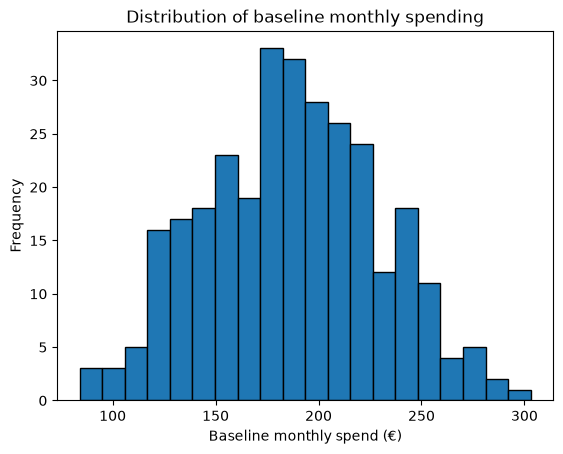

In [ ]:
customers["spend_baseline"].plot(
    kind="hist",
    bins=20,
    edgecolor="black",
    title="Distribution of baseline monthly spending",
)

plt.xlabel("Baseline monthly spend (€)")
plt.show()


## 17.2 Box plot by campaign


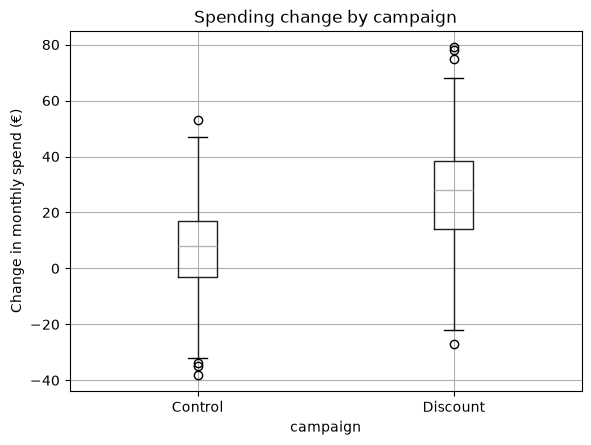

In [ ]:
customers.boxplot(
    column="spend_change",
    by="campaign"
)

plt.title("Spending change by campaign")
plt.suptitle("")
plt.ylabel("Change in monthly spend (€)")
plt.show()


## 17.3 Baseline versus post-campaign spending

The dashed diagonal represents `post-campaign = baseline`.

Points above the line correspond to an increase in monthly spending.


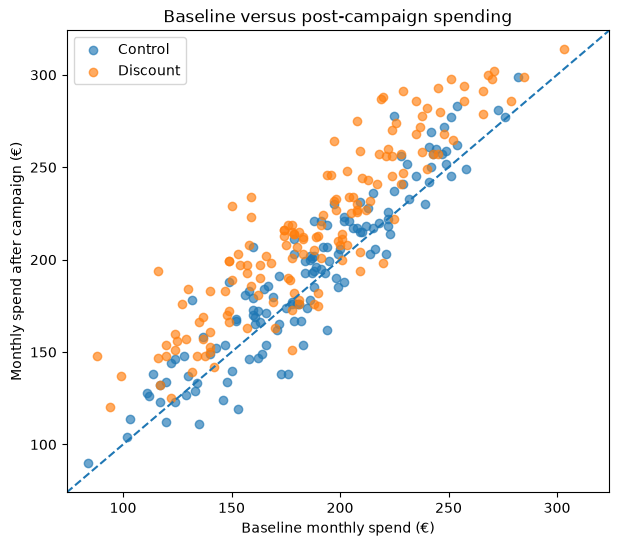

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for group, group_df in customers.groupby("campaign", observed=True):
    ax.scatter(
        group_df["spend_baseline"],
        group_df["spend_12w"],
        alpha=0.65,
        label=group,
    )

lower = customers["spend_baseline"].min() - 10
upper = customers[["spend_baseline", "spend_12w"]].max().max() + 10

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Baseline monthly spend (€)")
ax.set_ylabel("Monthly spend after campaign (€)")
ax.set_title("Baseline versus post-campaign spending")
ax.legend()
plt.show()


# 18. Method chaining

As analyses grow, repeatedly creating temporary variables can become difficult to read.

pandas supports **method chaining**, where several operations are written as one logical pipeline.

In [ ]:
summary = (
    customers
    .query("age >= 35")
    .assign(
        responded=lambda df: df["spend_change"] >= 20
    )
    .groupby("campaign", observed=True)
    .agg(
        n=("customer_id", "size"),
        mean_change=("spend_change", "mean"),
        response_rate=("responded", "mean"),
    )
    .sort_values("mean_change", ascending=False)
)

summary


,n,mean_change,response_rate
campaign,,,
Discount,115,27.22,0.63
Control,104,6.56,0.21


This style is especially useful when each step represents a clear transformation.

It is not mandatory: readability is more important than using the fewest lines possible.

# 19. Common pandas pitfalls

## 19.1 Chained assignment

Avoid code such as:

```python
subset = customers[customers["age"] > 50]
subset["high_value"] = True
```

Depending on the operation, pandas may warn that you are modifying a view rather than an independent DataFrame.

A safer pattern is:


In [ ]:
older_customers = customers.loc[
    customers["age"] > 50
].copy()

older_customers["high_value"] = (
    older_customers["spend_baseline"] >= 180
)

older_customers.head()


,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,signup_date,spend_change,high_value_baseline,engagement_category,age_group,meaningful_increase,site_visits_imputed,annual_income_imputed,city_upper,signup_month,signup_weekday,spend_rank,high_value
1,1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2026-03-29,2.0,True,Moderate,50–64,no,18.40,46318.5,PORDENONE,3,Sunday,78.0,True
2,1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,2026-03-04,45.0,True,Very high,50–64,yes,37.80,36913.0,GORIZIA,3,Wednesday,106.0,True
5,1006,63,Male,Trieste,yes,21.7,35639.0,Discount,266.0,291.0,2026-02-12,25.0,True,High,50–64,yes,21.70,35639.0,TRIESTE,2,Thursday,11.0,True
7,1008,55,Male,Udine,no,7.8,66751.0,Discount,179.0,182.0,2026-04-05,3.0,False,Low,50–64,no,7.80,66751.0,UDINE,4,Sunday,171.0,False
11,1012,69,Male,Trieste,yes,NaN,57596.0,Control,221.0,203.0,2026-06-17,-18.0,True,NaN,65+,no,20.35,57596.0,TRIESTE,6,Wednesday,68.0,True


## 19.2 Do not use `apply()` when a vectorized operation exists

This works:

In [ ]:
customers["age_plus_one_apply"] = customers["age"].apply(
    lambda x: x + 1
)


But this is simpler and usually faster:

In [ ]:
customers["age_plus_one"] = customers["age"] + 1


## 19.3 Be careful with equality and missing values

`NaN` does not behave like an ordinary number.

Use `.isna()` and `.notna()` instead of comparing with `np.nan`.

In [ ]:
customers.loc[
    customers["spend_12w"].isna(),
    ["customer_id", "spend_baseline", "spend_12w"]
].head()


,customer_id,spend_baseline,spend_12w
25,1026,206.0,NaN
35,1036,152.0,NaN
85,1086,185.0,NaN
108,1109,202.0,NaN
120,1121,120.0,NaN


## 19.4 Check assumptions before merging

Before merging tables, verify whether the key is unique when it should be.

In [ ]:
print("customers:", customers["customer_id"].is_unique)
print("touchpoints:", touchpoints["customer_id"].is_unique)


customers: True
touchpoints: True


# 20. Exporting processed data

After transformations, save only the variables needed for the next stage of the workflow.

In [ ]:
columns_to_export = [
    "customer_id",
    "age",
    "gender",
    "city",
    "loyalty_member",
    "site_visits",
    "annual_income",
    "campaign",
    "spend_baseline",
    "spend_12w",
    "spend_change",
    "high_value_baseline",
    "age_group",
    "engagement_category",
]

processed = customers[columns_to_export].copy()

processed.to_csv(
    "customer_data_processed.csv",
    index=False
)

processed.head()


,customer_id,age,gender,city,loyalty_member,site_visits,annual_income,campaign,spend_baseline,spend_12w,spend_change,high_value_baseline,age_group,engagement_category
0,1001,24,Male,Trieste,yes,14.8,51163.0,Control,178.0,177.0,-1.0,False,<50,Moderate
1,1002,59,Male,Pordenone,yes,18.4,NaN,Control,215.0,217.0,2.0,True,50–64,Moderate
2,1003,53,Female,Gorizia,yes,37.8,36913.0,Discount,203.0,248.0,45.0,True,50–64,Very high
3,1004,42,Male,Trieste,no,29.0,31077.0,Discount,191.0,219.0,28.0,True,<50,High
4,1005,42,Female,Trieste,no,NaN,30274.0,Control,117.0,132.0,15.0,False,<50,NaN


# 21. Mini-project: Does the discount campaign increase spending more?

Use the dataset to investigate whether customers assigned to the discount campaign show a larger increase in monthly spending than the control group.

Your analysis should:

1. count customers in each campaign group;
2. report missing post-campaign spending values by campaign;
3. compute mean and median spending change by campaign;
4. compute the proportion with a spending increase of at least €20;
5. compare results within the `<50`, `50–64`, and `65+` age groups;
6. create one useful visualization;
7. write two or three sentences interpreting the results.

### Important

This is an **exploratory analysis**. A difference in sample averages is not, by itself, sufficient to establish a causal or statistically significant campaign effect.


In [ ]:
# Your solution here

# 22. Possible solution to the mini-project

In [ ]:
analysis = (
    customers
    .dropna(subset=["spend_change"])
    .copy()
)

overall_summary = (
    analysis
    .groupby("campaign", observed=True)
    .agg(
        n=("customer_id", "size"),
        mean_change=("spend_change", "mean"),
        median_change=("spend_change", "median"),
        response_rate=(
            "spend_change",
            lambda x: (x >= 20).mean()
        ),
    )
)

overall_summary


,n,mean_change,median_change,response_rate
campaign,,,,
Control,137,6.74,8.0,0.20
Discount,148,27.29,28.0,0.67


In [ ]:
missing_followup = (
    customers
    .groupby("campaign", observed=True)
    .agg(
        total=("customer_id", "size"),
        missing_followup=("spend_12w", lambda x: x.isna().sum()),
    )
)

missing_followup["missing_%"] = (
    100
    * missing_followup["missing_followup"]
    / missing_followup["total"]
)

missing_followup


,total,missing_followup,missing_%
campaign,,,
Control,145,8,5.52
Discount,155,7,4.52


In [ ]:
age_summary = (
    analysis
    .groupby(
        ["age_group", "campaign"],
        observed=True
    )
    .agg(
        n=("customer_id", "size"),
        mean_change=("spend_change", "mean"),
        median_change=("spend_change", "median"),
    )
)

age_summary


n  mean_change  median_change
age_group campaign                                
<50       Control   83         9.24           10.0
          Discount  91        26.59           28.0
50–64     Control   40         1.77            1.5
          Discount  46        28.87           30.5
65+       Control   14         6.14            8.0
          Discount  11        26.45           30.0

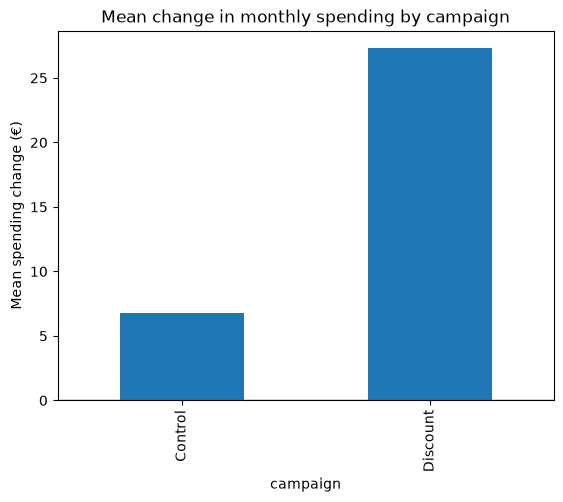

In [ ]:
group_means = (
    analysis
    .groupby("campaign", observed=True)["spend_change"]
    .mean()
)

group_means.plot(
    kind="bar",
    title="Mean change in monthly spending by campaign"
)

plt.ylabel("Mean spending change (€)")
plt.axhline(0, linewidth=1)
plt.show()


### Example interpretation

In this synthetic dataset, customers in the discount campaign tend to show a larger average increase in monthly spending than customers in the control group. The pattern can also be explored across age groups to check whether the average response is similar across customer segments. Because this is a simulated teaching dataset and the analysis is descriptive, these summaries should not be interpreted as evidence of a real causal campaign effect.


# 23. Additional exercises

## Exercise A — Data quality

Create a table reporting, for every column:

- data type;
- number of missing values;
- percentage missing;
- number of unique values.

Then identify the three columns with the highest percentage of missing data.

---

## Exercise B — Customer selection

Select customers who:

- are at least 40 years old;
- have baseline monthly spending above €180;
- are loyalty members **or** have annual income above €60,000.

Return only:

`customer_id`, `age`, `loyalty_member`, `annual_income`, `spend_baseline`.

---

## Exercise C — Derived high-value flag

Create a Boolean column called `multiple_value_signals` that is `True` when at least two of the following are true:

- age ≥ 45;
- loyalty member = `"yes"`;
- website visits ≥ 25;
- annual income ≥ €60,000;
- baseline monthly spending ≥ €180.

*Hint:* in Python, Boolean values behave like `1` and `0` when added.

---

## Exercise D — Missing post-campaign spending

Compare customers with and without a missing `spend_12w` measurement.

Do the two groups have similar:

- mean age?
- mean baseline spending?
- campaign distribution?

This is a simple way to start investigating whether missingness might be systematic.

---

## Exercise E — Merge validation

Create a duplicate row in the `touchpoints` table for one customer and try to merge with:

```python
validate="one_to_one"
```

What happens, and why is this useful?

---

## Exercise F — Long-format data

Convert `spend_baseline` and `spend_12w` to long format with `melt()` and compute mean spending for each:

- campaign;
- time point.

Then plot the four resulting means.


# 24. Take-home messages

- A pandas `DataFrame` represents a table; a `Series` usually represents one column.
- Inspect a dataset before modifying it.
- Use `.loc` for label-based selection and `.iloc` for position-based selection.
- Boolean masks, `.isin()`, `.between()`, and `.query()` are powerful filtering tools.
- Prefer vectorized operations over row-by-row Python loops.
- Missing values should be investigated and handled deliberately.
- `groupby()` is central for summarizing data.
- `transform()` preserves the original row structure, whereas `agg()` reduces groups.
- `pivot_table()` and `crosstab()` are useful for multidimensional summaries.
- `merge()` combines related tables; use `validate=` when possible.
- `melt()` and `pivot()` move between long and wide data representations.
- Outlier detection is a screening tool, not an automatic rule for deleting observations.
- Correlation describes association, not causality or independence.
- Method chaining can make data-cleaning pipelines easier to read.
- Use `.copy()` when creating a subset that you intend to modify.
- A reproducible analysis should make every transformation explicit.